In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [ ]:
file_path = "/content/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(file_path)
print("TASK 2: LOAD DATASET")
print("\nFirst 5 rows of the dataset:")
print(df.head())

TASK 2: LOAD DATASET

First 5 rows of the dataset:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4     

In [ ]:
print("\n" + "=" * 60)
print("TASK 3: SUMMARIZE DATASET")
print("=" * 60)

# Number of rows and columns
print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Total missing values
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())


TASK 3: SUMMARIZE DATASET

Number of Rows: 299
Number of Columns: 13

Column Names:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values in Each Column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets      

In [ ]:
df.loc[5, "age"] = np.nan
df.loc[15, "serum_creatinine"] = np.nan
df.loc[25, "ejection_fraction"] = np.nan
df.loc[35, "platelets"] = np.nan
df.loc[45, "smoking"] = np.nan
df.loc[55, "diabetes"] = np.nan
df.loc[65, "age"] = np.nan
df.loc[75, "serum_sodium"] = np.nan
df.loc[85, "serum_creatinine"] = np.nan
df.loc[95, "smoking"] = np.nan


print("\nControlled missing values have been introduced")
print("for demonstrating the cleaning process.")


Controlled missing values have been introduced
for demonstrating the cleaning process.


In [ ]:
print("\n" + "=" * 60)
print("TASK 4: VISUALIZE MISSING VALUES")
print("=" * 60)

# Count missing values in every column

missing_counts = df.isnull().sum()

print("\nMissing values after controlled introduction:")
print(missing_counts)


TASK 4: VISUALIZE MISSING VALUES

Missing values after controlled introduction:
age                         2
anaemia                     0
creatinine_phosphokinase    0
diabetes                    1
ejection_fraction           1
high_blood_pressure         0
platelets                   1
serum_creatinine            2
serum_sodium                1
sex                         0
smoking                     2
time                        0
DEATH_EVENT                 0
dtype: int64


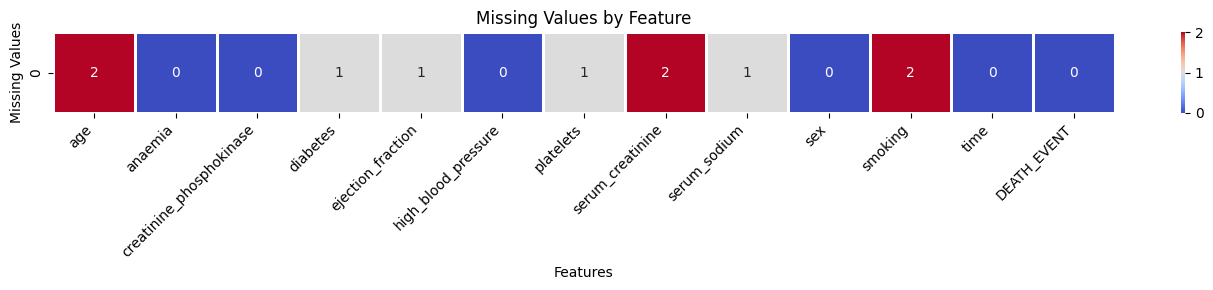

In [ ]:
plt.figure(figsize=(14, 3))

sns.heatmap(
    missing_counts.to_frame().T,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    linewidths=1,
    linecolor="white",
    cbar=True
)

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


TASK 5: PLOT DISTRIBUTIONS


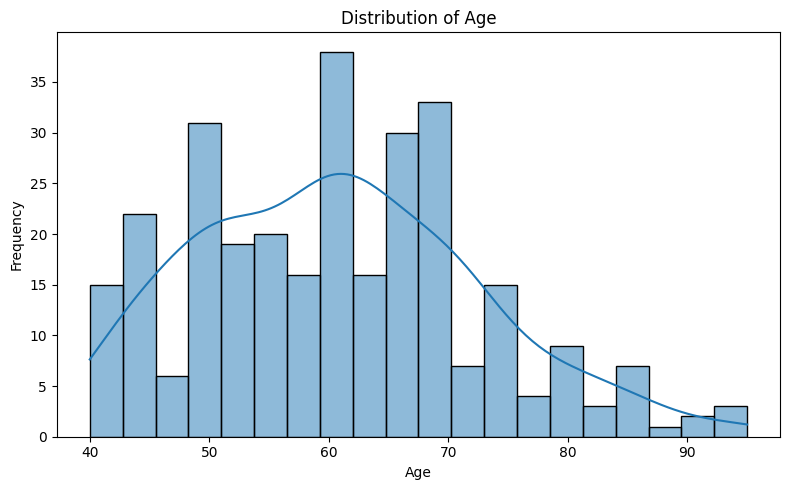

In [ ]:
print("\n" + "=" * 60)
print("TASK 5: PLOT DISTRIBUTIONS")
print("=" * 60)

# Histogram: Age
plt.figure(figsize=(8, 5))
sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

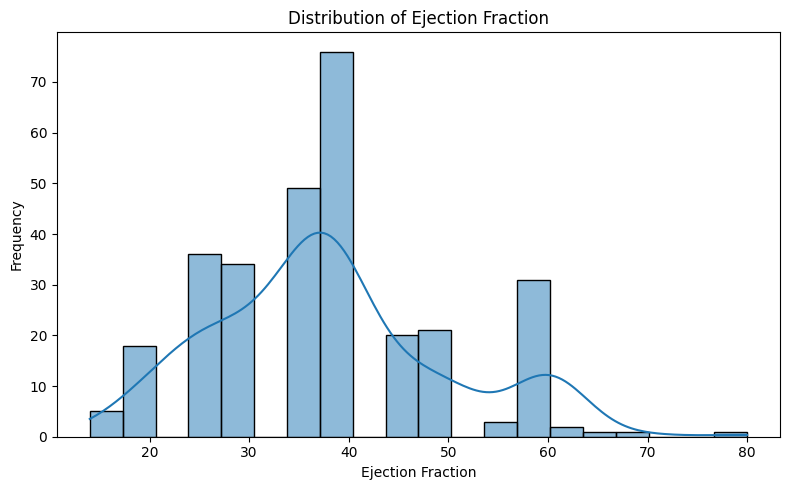

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["ejection_fraction"],
    bins=20,
    kde=True
)

plt.title("Distribution of Ejection Fraction")

plt.xlabel("Ejection Fraction")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

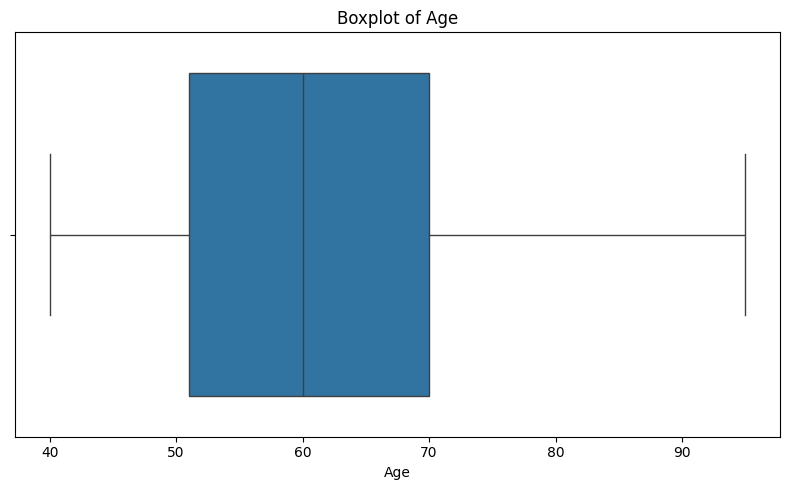

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df["age"]
)
plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

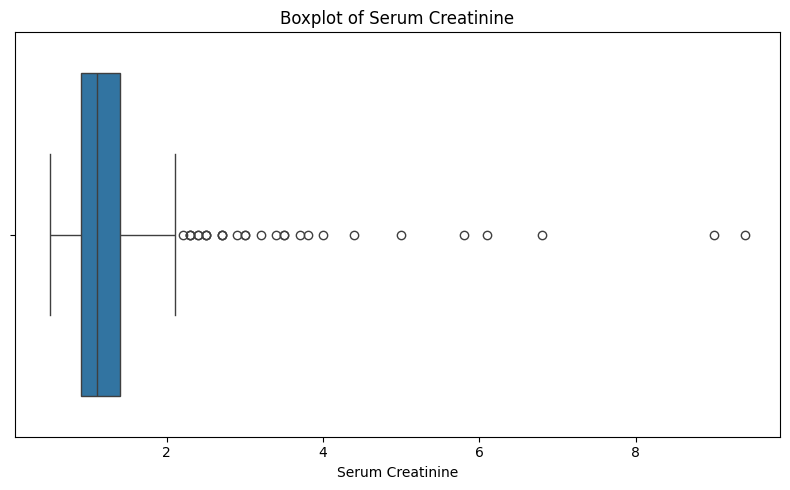

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df["serum_creatinine"]
)
plt.title("Boxplot of Serum Creatinine")
plt.xlabel("Serum Creatinine")
plt.tight_layout()
plt.show()

In [ ]:
before_cleaning_mean = df.mean(numeric_only=True)

before_cleaning_median = df.median(numeric_only=True)

before_cleaning_std = df.std(numeric_only=True)

In [ ]:
print("TASK 6: IMPUTE MISSING VALUES")

# Numerical Features
numerical_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]
for column in numerical_columns:
    if df[column].isnull().sum() > 0:
        median_value = df[column].median()
        df[column] = df[column].fillna(
            median_value
        )
        print(
            f"{column}: Missing values replaced "
            f"with median = {median_value}"
        )
        categorical_columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
]
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        mode_value = df[column].mode()[0]
        df[column] = df[column].fillna(
            mode_value
        )
        print(
            f"{column}: Missing values replaced "
            f"with mode = {mode_value}"
        )
print("\nMissing values after imputation:")
print(df.isnull().sum())

TASK 6: IMPUTE MISSING VALUES

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
categorical_columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
]
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        mode_value = df[column].mode()[0]
        df[column] = df[column].fillna(
            mode_value
        )
        print(
            f"{column}: Missing values replaced "
            f"with mode = {mode_value}"
        )
print("\nMissing values after imputation:")
print(df.isnull().sum())

diabetes: Missing values replaced with mode = 0.0
smoking: Missing values replaced with mode = 0.0

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
print("TASK 7: REMOVE OUTLIERS")
# Numerical columns on which outlier detection is performed
outlier_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]
rows_before_outlier_removal = len(df)
# IQR method
for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]
rows_after_outlier_removal = len(df)
print("\nRows before outlier removal:",
      rows_before_outlier_removal)
print("Rows after outlier removal:",
      rows_after_outlier_removal)
print(
    "Total rows removed:",
    rows_before_outlier_removal -
    rows_after_outlier_removal
)

TASK 7: REMOVE OUTLIERS

Rows before outlier removal: 299
Rows after outlier removal: 224
Total rows removed: 75


In [ ]:
print("TASK 8: CORRECT INCONSISTENCIES")

# Check negative age
negative_age = df[df["age"] < 0]
print("\nNegative age entries:")
print(negative_age)

# Check negative ejection fraction
negative_ejection_fraction = df[
    df["ejection_fraction"] < 0
]
print("\nNegative ejection fraction entries:")
print(negative_ejection_fraction)

# Check negative serum creatinine
negative_serum_creatinine = df[
    df["serum_creatinine"] < 0
]
print("\nNegative serum creatinine entries:")
print(negative_serum_creatinine)

# Check invalid sex values
# Valid values = 0 or 1
invalid_sex = df[
    (~df["sex"].isin([0, 1])) &
    (df["sex"].notna())
]
print("\nInvalid sex entries:")
print(invalid_sex)

# Check invalid smoking values
# Valid values = 0 or 1
invalid_smoking = df[
    (~df["smoking"].isin([0, 1])) &
    (df["smoking"].notna())
]
print("\nInvalid smoking entries:")
print(invalid_smoking)

TASK 8: CORRECT INCONSISTENCIES

Negative age entries:
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []

Negative ejection fraction entries:
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []

Negative serum creatinine entries:
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []

Invalid sex entries:
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []

Invalid smoking entries:
Empty DataFrame


In [ ]:
df.loc[df["age"] < 0, "age"] = np.nan
df.loc[
    df["ejection_fraction"] < 0,
    "ejection_fraction"
] = np.nan
df.loc[
    df["serum_creatinine"] < 0,
    "serum_creatinine"
] = np.nan

# If any invalid values were converted to NaN,
# fill them using the median.
df["age"] = df["age"].fillna(df["age"].median())
df["ejection_fraction"] = df[
    "ejection_fraction"
].fillna(
    df["ejection_fraction"].median()
)
df["serum_creatinine"] = df[
    "serum_creatinine"
].fillna(
    df["serum_creatinine"].median()
)
print("\nInvalid values have been corrected.")


Invalid values have been corrected.


In [ ]:
print("TASK 9: FEATURE ENGINEERING")
# 9.1 CREATE age_group
# <40
# 40-60
# >60
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)
print("\nAge Group Distribution:")
print(df["age_group"].value_counts())

# 9.2 CREATE risk_score
# Normalize:
# ejection_fraction
# serum_creatinine
# Then calculate their product.

ejection_min = df["ejection_fraction"].min()
ejection_max = df["ejection_fraction"].max()
df["ejection_fraction_norm"] = (
    df["ejection_fraction"] - ejection_min
) / (
    ejection_max - ejection_min
)
creatinine_min = df["serum_creatinine"].min()
creatinine_max = df["serum_creatinine"].max()
df["serum_creatinine_norm"] = (
    df["serum_creatinine"] - creatinine_min
) / (
    creatinine_max - creatinine_min
)
df["risk_score"] = (
    df["ejection_fraction_norm"]
    *
    df["serum_creatinine_norm"]
)
print("\nFirst 5 risk scores:")
print(df["risk_score"].head())

TASK 9: FEATURE ENGINEERING

Age Group Distribution:
age_group
>60      125
40-60     99
<40        0
Name: count, dtype: int64

First 5 risk scores:
0    0.101961
2    0.054902
3    0.101961
5    0.509804
6    0.007843
Name: risk_score, dtype: float64


In [ ]:
# TASK 10: ENCODE CATEGORICAL VARIABLES
# Apply one-hot encoding

print("TASK 10: ENCODE CATEGORICAL VARIABLES")
# One-hot encode:
# sex
# smoking
# age_group
df = pd.get_dummies(
    df,
    columns=[
        "sex",
        "smoking",
        "age_group"
    ],
    prefix=[
        "sex",
        "smoking",
        "age_group"
    ],
    dtype=int
)
print("\nDataset after categorical encoding:")
print(df.head())

TASK 10: ENCODE CATEGORICAL VARIABLES

Dataset after categorical encoding:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582       0.0               20.0   
2  65.0        0                       146       0.0               20.0   
3  50.0        1                       111       0.0               20.0   
5  60.0        1                        47       0.0               40.0   
6  75.0        1                       246       0.0               15.0   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  time  ...  \
0                    1   265000.0               1.9         130.0     4  ...   
2                    0   162000.0               1.3         129.0     7  ...   
3                    0   210000.0               1.9         137.0     7  ...   
5                    1   204000.0               2.1         132.0     8  ...   
6                    0   127000.0               1.2         137.0    10  .

In [ ]:
# TASK 11: NORMALIZE FEATURES
# Scale numerical features from 0 to 1 using MinMaxScaler

print("TASK 11: NORMALIZE FEATURES")
scaler = MinMaxScaler()
features_to_scale = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]
df[features_to_scale] = scaler.fit_transform(
    df[features_to_scale]
)
print("\nNormalized numerical features:")
print(df[features_to_scale].head())

TASK 11: NORMALIZE FEATURES

Normalized numerical features:
        age  creatinine_phosphokinase  ejection_fraction  platelets  \
0  0.636364                  0.470990           0.117647   0.468852   
2  0.454545                  0.098976           0.117647   0.131148   
3  0.181818                  0.069113           0.117647   0.288525   
5  0.363636                  0.014505           0.509804   0.268852   
6  0.636364                  0.184300           0.019608   0.016393   

   serum_creatinine  serum_sodium      time  
0          0.866667      0.217391  0.000000  
2          0.466667      0.173913  0.010676  
3          0.866667      0.521739  0.010676  
5          1.000000      0.304348  0.014235  
6          0.400000      0.521739  0.021352  


In [ ]:
# TASK 12: COMPUTE SUMMARY STATISTICS
# Calculate mean, median and standard deviation
# BEFORE and AFTER cleaning

print("TASK 12: SUMMARY STATISTICS")

# BEFORE CLEANING
print("\n BEFORE CLEANING ")
print("\nMean:")
print(before_cleaning_mean)
print("\nMedian:")
print(before_cleaning_median)
print("\nStandard Deviation:")
print(before_cleaning_std)

TASK 12: SUMMARY STATISTICS

 BEFORE CLEANING 

Mean:
age                             60.738498
anaemia                          0.431438
creatinine_phosphokinase       581.839465
diabetes                         0.419463
ejection_fraction               38.083893
high_blood_pressure              0.351171
platelets                   263476.680369
serum_creatinine                 1.396532
serum_sodium                   136.617450
sex                              0.648829
smoking                          0.319865
time                           130.260870
DEATH_EVENT                      0.321070
dtype: float64

Median:
age                             60.0
anaemia                          0.0
creatinine_phosphokinase       250.0
diabetes                         0.0
ejection_fraction               38.0
high_blood_pressure              0.0
platelets                   262500.0
serum_creatinine                 1.1
serum_sodium                   137.0
sex                              1.0
smokin

In [ ]:
# AFTER CLEANING
after_cleaning_mean = df.mean(
    numeric_only=True
)
after_cleaning_median = df.median(
    numeric_only=True
)
after_cleaning_std = df.std(
    numeric_only=True
)
print("\n AFTER CLEANING ")
print("\nMean:")
print(after_cleaning_mean)
print("\nMedian:")
print(after_cleaning_median)
print("\nStandard Deviation:")
print(after_cleaning_std)


 AFTER CLEANING 

Mean:
age                         0.375920
anaemia                     0.468750
creatinine_phosphokinase    0.261896
diabetes                    0.419643
ejection_fraction           0.474090
high_blood_pressure         0.379464
platelets                   0.438902
serum_creatinine            0.353571
serum_sodium                0.523292
time                        0.457836
DEATH_EVENT                 0.272321
ejection_fraction_norm      0.474090
serum_creatinine_norm       0.353571
risk_score                  0.158031
sex_0                       0.357143
sex_1                       0.642857
smoking_0.0                 0.683036
smoking_1.0                 0.316964
age_group_<40               0.000000
age_group_40-60             0.441964
age_group_>60               0.558036
dtype: float64

Median:
age                         0.363636
anaemia                     0.000000
creatinine_phosphokinase    0.155290
diabetes                    0.000000
ejection_fraction         

TASK 13: VALIDATE CLEANING


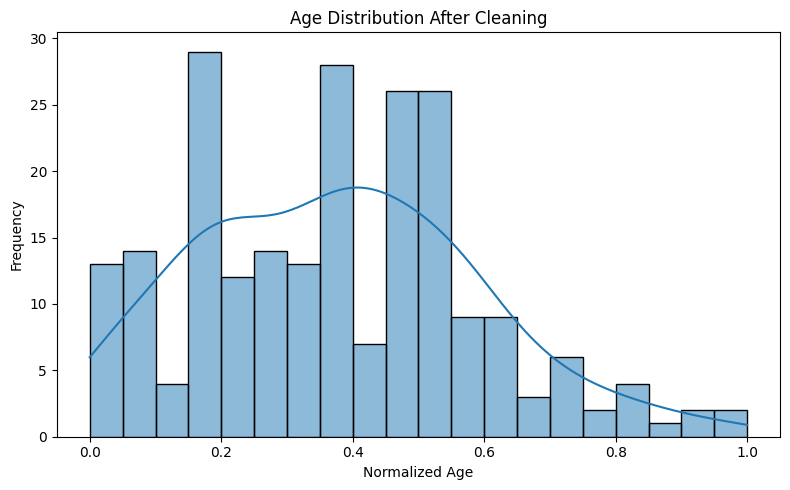

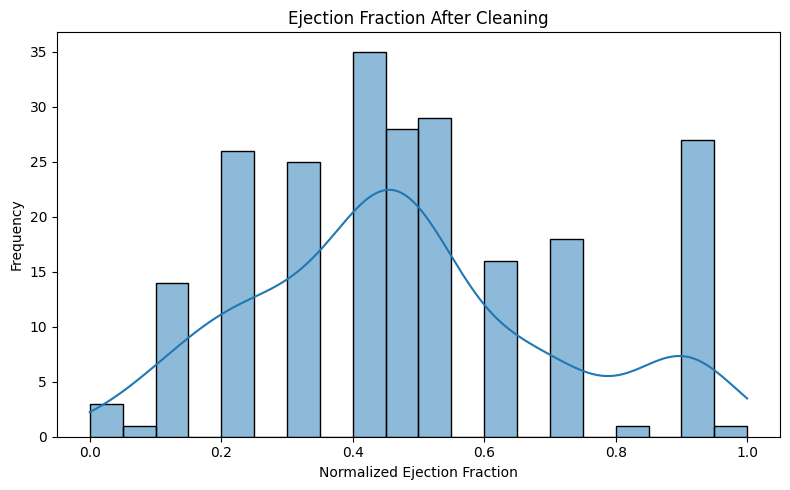

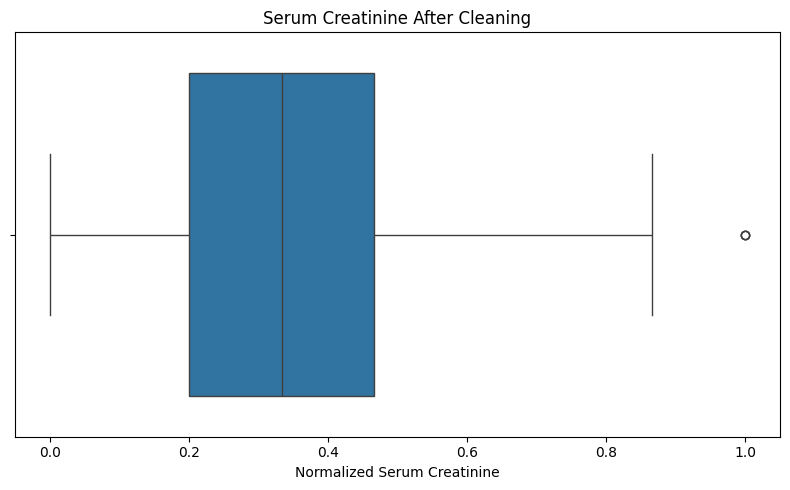

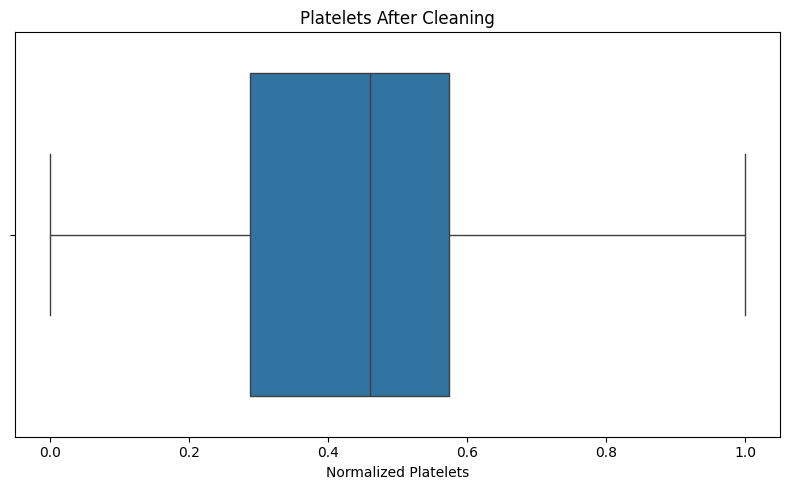

In [ ]:
# TASK 13: VALIDATE CLEANING
# Plot histograms / boxplots for cleaned features

print("TASK 13: VALIDATE CLEANING")

# Cleaned Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(
    df["age"],
    bins=20,
    kde=True
)
plt.title("Age Distribution After Cleaning")
plt.xlabel("Normalized Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Cleaned Ejection Fraction
plt.figure(figsize=(8, 5))
sns.histplot(
    df["ejection_fraction"],
    bins=20,
    kde=True
)
plt.title("Ejection Fraction After Cleaning")
plt.xlabel("Normalized Ejection Fraction")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Cleaned Serum Creatinine
plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df["serum_creatinine"]
)
plt.title("Serum Creatinine After Cleaning")
plt.xlabel("Normalized Serum Creatinine")
plt.tight_layout()
plt.show()

# Cleaned Platelets
plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df["platelets"]
)
plt.title("Platelets After Cleaning")
plt.xlabel("Normalized Platelets")
plt.tight_layout()
plt.show()

In [ ]:
# TASK 14: CHECK MISSING VALUES
# Confirm no missing values remain
print("TASK 14: FINAL MISSING VALUE CHECK")
final_missing_values = df.isnull().sum()
print("\nMissing values in each column:")
print(final_missing_values)
total_missing_values = final_missing_values.sum()
print(
    "\nTotal Missing Values:",
    total_missing_values
)
if total_missing_values == 0:
    print("\nSUCCESS!")
    print("No missing values remain after cleaning.")
else:
    print("\nSome missing values still remain.")

# FINAL DATASET
print("\n" + "=" * 60)
print("FINAL CLEANED DATASET")
print("=" * 60)
print("\nFinal Shape:")
print(df.shape)
print("\nFinal Columns:")
print(df.columns.tolist())
print("\nFirst 5 rows of cleaned dataset:")
print(df.head())

# SAVE CLEANED DATASET
output_file = "cleaned_heart_failure_dataset.csv"
df.to_csv(
    output_file,
    index=False
)
print("\nCleaned dataset saved as:")
print(output_file)

TASK 14: FINAL MISSING VALUE CHECK

Missing values in each column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
time                        0
DEATH_EVENT                 0
ejection_fraction_norm      0
serum_creatinine_norm       0
risk_score                  0
sex_0                       0
sex_1                       0
smoking_0.0                 0
smoking_1.0                 0
age_group_<40               0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total Missing Values: 0

SUCCESS!
No missing values remain after cleaning.

FINAL CLEANED DATASET

Final Shape:
(224, 21)

Final Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium',